In [22]:
import os
import glob
import netCDF4
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import gridspec
import cartopy.crs as ccrs
import cartopy.feature
import seaborn as sns

import wrf
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import matplotlib.ticker as mticker
import matplotlib.colors

import matplotlib as mpl

In [23]:
######################
# FUNCTIONS
######################

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]

In [24]:
######################
# ALPS HIST
print('Charging Ant hist...')

#Parameters
folder_mod = '/capstor/scratch/cscs/gsergi/OUTPUT_PGW_20220315/ANT_20220315_'
domain = 'd01'
acc_t = 1440 #minutes
ini_date_idx=0
tini_ix = 39
#end_date_idx=0

###load data###
snpack_files = '/SMB/SMB_'+domain+'_*'# Load netcdf
outhist_files = '/outhist/outhist_'+domain+'_*'# Load netcdf

################
#hist
wrflist_smb = []
wrflist_out = []
proj = 'hist'
print('Total: ' + str(np.size(glob.glob(folder_mod+proj+snpack_files))))
for i,ncdf_smb in enumerate(np.sort(glob.glob(folder_mod+proj+snpack_files))):
        print(i, end="\r")
        wrflist_smb.append(netCDF4.Dataset(ncdf_smb))

print('Total: ' + str(np.size(glob.glob(folder_mod+proj+outhist_files))))
for i,ncdf_out in enumerate(np.sort(glob.glob(folder_mod+proj+outhist_files))):
        print(i, end="\r")
        wrflist_out.append(netCDF4.Dataset(ncdf_out))
    
# Get surface variables
sigma = 5.670374419E-8
TSK = wrf.getvar(wrflist_out, 'TSK', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:]
E_LWINC_hist = wrf.getvar(wrflist_out, 'GLW', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:]
E_LWOUT_hist = -0.98*sigma*TSK**4
E_LWNET_hist = E_LWINC_hist + E_LWOUT_hist
E_SWINC_hist = wrf.getvar(wrflist_out, 'SWDOWN', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:]
E_SWNET_hist = wrf.getvar(wrflist_out, 'GSW', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:]
E_SWOUT_hist = E_SWNET_hist - E_SWINC_hist
E_SENSH_hist = wrf.getvar(wrflist_smb, 'HFX', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:]
E_LATEH_hist = wrf.getvar(wrflist_smb, 'LH', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:]
E_TOTAL_hist = E_LWINC_hist + E_LWOUT_hist + E_SWINC_hist + E_SWOUT_hist - E_SENSH_hist - E_LATEH_hist

################
#past
print('Charging Ant past...')
wrflist_smb = []
wrflist_out = []
proj = 'past_new'
print('Total: ' + str(np.size(glob.glob(folder_mod+proj+snpack_files))))
for i,ncdf_smb in enumerate(np.sort(glob.glob(folder_mod+proj+snpack_files))):
        print(i, end="\r")
        wrflist_smb.append(netCDF4.Dataset(ncdf_smb))

print('Total: ' + str(np.size(glob.glob(folder_mod+proj+outhist_files))))
for i,ncdf_out in enumerate(np.sort(glob.glob(folder_mod+proj+outhist_files))):
        print(i, end="\r")
        wrflist_out.append(netCDF4.Dataset(ncdf_out))

sigma = 5.670374419E-8
TSK = wrf.getvar(wrflist_out, 'TSK', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:]
E_LWINC_past = wrf.getvar(wrflist_out, 'GLW', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:]
E_LWOUT_past = -0.98*sigma*TSK**4
E_LWNET_past = E_LWINC_past + E_LWOUT_past
E_SWINC_past = wrf.getvar(wrflist_out, 'SWDOWN', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:]
E_SWNET_past = wrf.getvar(wrflist_out, 'GSW', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:]
E_SWOUT_past = E_SWNET_past - E_SWINC_past
E_SENSH_past = wrf.getvar(wrflist_smb, 'HFX', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:]
E_LATEH_past = wrf.getvar(wrflist_smb, 'LH', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:]
E_TOTAL_past = E_LWINC_past + E_LWOUT_past + E_SWINC_past + E_SWOUT_past - E_SENSH_past - E_LATEH_past

######################
# ANT COORDINATES
# Get surface fix variables
height = wrf.getvar(wrflist_smb, 'HGT', timeidx=0, method="cat")[:,:]
# Get dimension
lats, lons = wrf.latlon_coords(E_SENSH_hist)
times = wrf.extract_times(wrflist_smb, timeidx=wrf.ALL_TIMES)

Charging Ant hist...
Total: 59
Total: 59
Charging Ant past...
Total: 59
Total: 59


In [25]:
#Positions
CON_xy = wrf.ll_to_xy(wrflist_smb, -75.09978, 123.332196) #Concordia
CON_ll = wrf.xy_to_ll(wrflist_smb, CON_xy[0], CON_xy[1])
DDU_xy = wrf.ll_to_xy(wrflist_smb, -66.662778, 140.001111) #DDU
DDU_ll = wrf.xy_to_ll(wrflist_smb, DDU_xy[0], DDU_xy[1])
CIS_xy = wrf.ll_to_xy(wrflist_smb, -66.033333, 103.55) #DDU
CIS_ll = wrf.xy_to_ll(wrflist_smb, CIS_xy[0], CIS_xy[1])

/tmp/ipykernel_125563/2101509524.py:37: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  ax9.plot(wrf.to_np(CON_xy)[0], wrf.to_np(CON_xy)[1], 'ko', markersize=5, color='k')


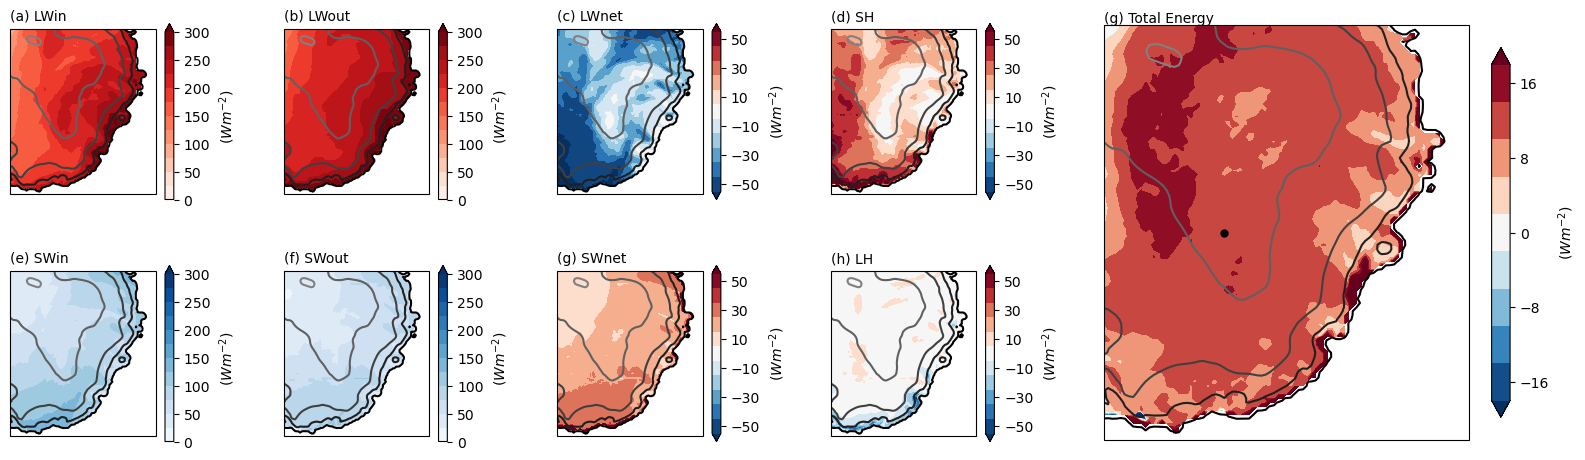

In [26]:
#############################################
# Plot terrein map
#############################################

min_height = 10

time_ix_ini = np.where(times == np.datetime64('2022-03-17T00'))[0][0]
time_ix_end = np.where(times == np.datetime64('2022-03-20T00'))[0][0]
  
#################
### Plot Norm ###
#Figure and axis
fig = plt.figure(figsize=[20,6])
spec = gridspec.GridSpec(ncols=6, nrows=2, figure=fig, hspace= 0.1, wspace=0.5)

### Background
ax1 = fig.add_subplot(spec[0, 0], projection=ccrs.SouthPolarStereo())
ax2 = fig.add_subplot(spec[0, 1], projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(spec[0, 2], projection=ccrs.SouthPolarStereo())
ax4 = fig.add_subplot(spec[0, 3], projection=ccrs.SouthPolarStereo())
ax5 = fig.add_subplot(spec[1, 0], projection=ccrs.SouthPolarStereo())
ax6 = fig.add_subplot(spec[1, 1], projection=ccrs.SouthPolarStereo())
ax7 = fig.add_subplot(spec[1, 2], projection=ccrs.SouthPolarStereo())
ax8 = fig.add_subplot(spec[1, 3], projection=ccrs.SouthPolarStereo())
ax9 = fig.add_subplot(spec[:, 4:], projection=ccrs.SouthPolarStereo())

CS1 = ax1.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS2 = ax2.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS3 = ax3.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS4 = ax4.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS5 = ax5.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS6 = ax6.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS7 = ax7.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS8 = ax8.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS9 = ax9.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")

ax9.plot(wrf.to_np(CON_xy)[0], wrf.to_np(CON_xy)[1], 'ko', markersize=5, color='k')

#Calculate difference between the beginning and the end of the event
E_LWINC_hist_event_mean = wrf.to_np(E_LWINC_hist[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_LWOUT_hist_event_mean = wrf.to_np(-E_LWOUT_hist[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_SWINC_hist_event_mean = wrf.to_np(E_SWINC_hist[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_SWOUT_hist_event_mean = wrf.to_np(-E_SWOUT_hist[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_SENSH_hist_event_mean = wrf.to_np(E_SENSH_hist[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_LATEH_hist_event_mean = wrf.to_np(E_LATEH_hist[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_TOTAL_hist_event_mean = wrf.to_np(E_TOTAL_hist[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)

fill1 = ax1.contourf(E_LWINC_hist_event_mean, np.arange(0,300.1,25), cmap='Reds', extend="max")
fill2 = ax2.contourf(E_LWOUT_hist_event_mean, np.arange(0,300.1,25), cmap='Reds', extend="max")
fill3 = ax3.contourf(E_LWINC_hist_event_mean - E_LWOUT_hist_event_mean, np.arange(-55,55.1,10), cmap='RdBu_r', extend="both")

fill5 = ax5.contourf(E_SWINC_hist_event_mean, np.arange(0,300.1,25), cmap='Blues', extend="max")
fill6 = ax6.contourf(E_SWOUT_hist_event_mean, np.arange(0,300.1,25), cmap='Blues', extend="max")
fill7 = ax7.contourf(E_SWINC_hist_event_mean-E_SWOUT_hist_event_mean, np.arange(-55,55.1,10), cmap='RdBu_r', extend="both")

fill4 = ax4.contourf(-E_SENSH_hist_event_mean, np.arange(-55,55.1,10), cmap='RdBu_r', extend="both")
fill8 = ax8.contourf(-E_LATEH_hist_event_mean, np.arange(-55,55.1,10), cmap='RdBu_r', extend="both")

ax1.set_title('(a) LWin', loc='left', fontsize=10)
ax2.set_title('(b) LWout', loc='left', fontsize=10)
ax3.set_title('(c) LWnet', loc='left', fontsize=10)

ax5.set_title('(e) SWin', loc='left', fontsize=10)
ax6.set_title('(f) SWout', loc='left', fontsize=10)
ax7.set_title('(g) SWnet', loc='left', fontsize=10)

ax4.set_title('(d) SH', loc='left', fontsize=10)
ax8.set_title('(h) LH', loc='left', fontsize=10)

cbar1 = plt.colorbar(fill1, shrink=0.8, ax=ax1); cbar1.set_label('($Wm^{-2}$)', labelpad=5)
cbar2 = plt.colorbar(fill2, shrink=0.8, ax=ax2); cbar2.set_label('($Wm^{-2}$)', labelpad=5)
cbar3 = plt.colorbar(fill3, shrink=0.8, ax=ax3); cbar3.set_label('($Wm^{-2}$)', labelpad=5)
cbar4 = plt.colorbar(fill4, shrink=0.8, ax=ax4); cbar4.set_label('($Wm^{-2}$)', labelpad=5)
cbar5 = plt.colorbar(fill5, shrink=0.8, ax=ax5); cbar5.set_label('($Wm^{-2}$)', labelpad=5)
cbar6 = plt.colorbar(fill6, shrink=0.8, ax=ax6); cbar6.set_label('($Wm^{-2}$)', labelpad=5)
cbar7 = plt.colorbar(fill7, shrink=0.8, ax=ax7); cbar7.set_label('($Wm^{-2}$)', labelpad=5)
cbar8 = plt.colorbar(fill8, shrink=0.8, ax=ax8); cbar8.set_label('($Wm^{-2}$)', labelpad=5)

fill9 = ax9.contourf(E_TOTAL_hist_event_mean, np.arange(-18,18.1,4), cmap='RdBu_r', extend="both")
#fill9 = ax9.contourf(E_LWINC_hist_event_mean - E_LWOUT_hist_event_mean + E_SWINC_hist_event_mean-E_SWOUT_hist_event_mean - E_SENSH_hist_event_mean - E_LATEH_hist_event_mean, np.arange(-600,600.1,50), cmap='RdBu_r', extend="both")
cbar9 = plt.colorbar(fill9, shrink=0.8, ax=ax9)
cbar9.set_label('($Wm^{-2}$)', labelpad=5)
ax9.set_title('(g) Total Energy', pad=-2000, loc='left', fontsize=10)

cbar3.set_ticks(np.arange(-50,50.1,20))
cbar4.set_ticks(np.arange(-50,50.1,20))
cbar7.set_ticks(np.arange(-50,50.1,20))
cbar8.set_ticks(np.arange(-50,50.1,20))
cbar9.set_ticks(np.arange(-16,16.1,8))

for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]:
    ax.set_extent([132, 220, 30, 130], crs=ccrs.SouthPolarStereo())

/tmp/ipykernel_125563/4128715744.py:37: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  ax9.plot(wrf.to_np(CON_xy)[0], wrf.to_np(CON_xy)[1], 'ko', markersize=5, color='k')


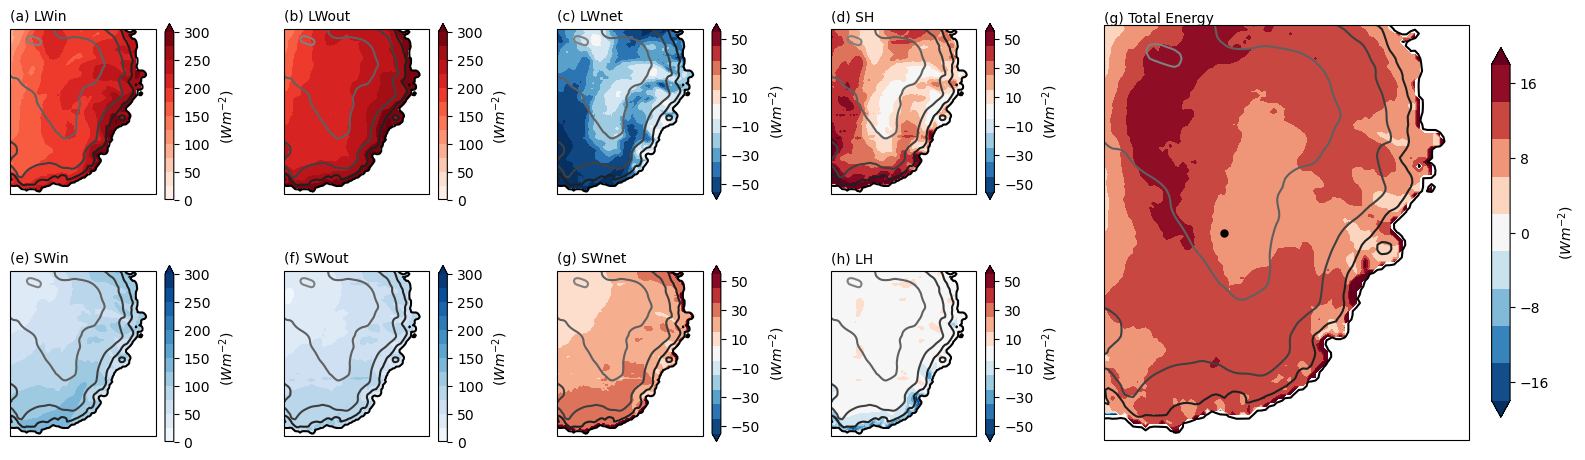

In [27]:
#############################################
# Plot terrein map
#############################################

min_height = 10

time_ix_ini = np.where(times == np.datetime64('2022-03-17T00'))[0][0]
time_ix_end = np.where(times == np.datetime64('2022-03-20T00'))[0][0]
  
#################
### Plot Norm ###
#Figure and axis
fig = plt.figure(figsize=[20,6])
spec = gridspec.GridSpec(ncols=6, nrows=2, figure=fig, hspace= 0.1, wspace=0.5)

### Background
ax1 = fig.add_subplot(spec[0, 0], projection=ccrs.SouthPolarStereo())
ax2 = fig.add_subplot(spec[0, 1], projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(spec[0, 2], projection=ccrs.SouthPolarStereo())
ax4 = fig.add_subplot(spec[0, 3], projection=ccrs.SouthPolarStereo())
ax5 = fig.add_subplot(spec[1, 0], projection=ccrs.SouthPolarStereo())
ax6 = fig.add_subplot(spec[1, 1], projection=ccrs.SouthPolarStereo())
ax7 = fig.add_subplot(spec[1, 2], projection=ccrs.SouthPolarStereo())
ax8 = fig.add_subplot(spec[1, 3], projection=ccrs.SouthPolarStereo())
ax9 = fig.add_subplot(spec[:, 4:], projection=ccrs.SouthPolarStereo())

CS1 = ax1.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS2 = ax2.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS3 = ax3.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS4 = ax4.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS5 = ax5.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS6 = ax6.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS7 = ax7.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS8 = ax8.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS9 = ax9.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")

ax9.plot(wrf.to_np(CON_xy)[0], wrf.to_np(CON_xy)[1], 'ko', markersize=5, color='k')

#Calculate difference between the beginning and the end of the event
E_LWINC_past_event_mean = wrf.to_np(E_LWINC_past[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_LWOUT_past_event_mean = wrf.to_np(-E_LWOUT_past[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_SWINC_past_event_mean = wrf.to_np(E_SWINC_past[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_SWOUT_past_event_mean = wrf.to_np(-E_SWOUT_past[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_SENSH_past_event_mean = wrf.to_np(E_SENSH_past[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_LATEH_past_event_mean = wrf.to_np(E_LATEH_past[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_TOTAL_past_event_mean = wrf.to_np(E_TOTAL_past[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)

fill1 = ax1.contourf(E_LWINC_past_event_mean, np.arange(0,300.1,25), cmap='Reds', extend="max")
fill2 = ax2.contourf(E_LWOUT_past_event_mean, np.arange(0,300.1,25), cmap='Reds', extend="max")
fill3 = ax3.contourf(E_LWINC_past_event_mean - E_LWOUT_past_event_mean, np.arange(-55,55.1,10), cmap='RdBu_r', extend="both")

fill5 = ax5.contourf(E_SWINC_past_event_mean, np.arange(0,300.1,25), cmap='Blues', extend="max")
fill6 = ax6.contourf(E_SWOUT_past_event_mean, np.arange(0,300.1,25), cmap='Blues', extend="max")
fill7 = ax7.contourf(E_SWINC_past_event_mean-E_SWOUT_past_event_mean, np.arange(-55,55.1,10), cmap='RdBu_r', extend="both")

fill4 = ax4.contourf(-E_SENSH_past_event_mean, np.arange(-55,55.1,10), cmap='RdBu_r', extend="both")
fill8 = ax8.contourf(-E_LATEH_past_event_mean, np.arange(-55,55.1,10), cmap='RdBu_r', extend="both")

ax1.set_title('(a) LWin', loc='left', fontsize=10)
ax2.set_title('(b) LWout', loc='left', fontsize=10)
ax3.set_title('(c) LWnet', loc='left', fontsize=10)

ax5.set_title('(e) SWin', loc='left', fontsize=10)
ax6.set_title('(f) SWout', loc='left', fontsize=10)
ax7.set_title('(g) SWnet', loc='left', fontsize=10)

ax4.set_title('(d) SH', loc='left', fontsize=10)
ax8.set_title('(h) LH', loc='left', fontsize=10)

cbar1 = plt.colorbar(fill1, shrink=0.8, ax=ax1); cbar1.set_label('($Wm^{-2}$)', labelpad=5)
cbar2 = plt.colorbar(fill2, shrink=0.8, ax=ax2); cbar2.set_label('($Wm^{-2}$)', labelpad=5)
cbar3 = plt.colorbar(fill3, shrink=0.8, ax=ax3); cbar3.set_label('($Wm^{-2}$)', labelpad=5)
cbar4 = plt.colorbar(fill4, shrink=0.8, ax=ax4); cbar4.set_label('($Wm^{-2}$)', labelpad=5)
cbar5 = plt.colorbar(fill5, shrink=0.8, ax=ax5); cbar5.set_label('($Wm^{-2}$)', labelpad=5)
cbar6 = plt.colorbar(fill6, shrink=0.8, ax=ax6); cbar6.set_label('($Wm^{-2}$)', labelpad=5)
cbar7 = plt.colorbar(fill7, shrink=0.8, ax=ax7); cbar7.set_label('($Wm^{-2}$)', labelpad=5)
cbar8 = plt.colorbar(fill8, shrink=0.8, ax=ax8); cbar8.set_label('($Wm^{-2}$)', labelpad=5)

fill9 = ax9.contourf(E_TOTAL_past_event_mean, np.arange(-18,18.1,4), cmap='RdBu_r', extend="both")
#fill9 = ax9.contourf(E_LWINC_past_event_mean - E_LWOUT_past_event_mean + E_SWINC_past_event_mean-E_SWOUT_past_event_mean - E_SENSH_past_event_mean - E_LATEH_past_event_mean, np.arange(-600,600.1,50), cmap='RdBu_r', extend="both")
cbar9 = plt.colorbar(fill9, shrink=0.8, ax=ax9)
cbar9.set_label('($Wm^{-2}$)', labelpad=5)
ax9.set_title('(g) Total Energy', pad=-2000, loc='left', fontsize=10)

cbar3.set_ticks(np.arange(-50,50.1,20))
cbar4.set_ticks(np.arange(-50,50.1,20))
cbar7.set_ticks(np.arange(-50,50.1,20))
cbar8.set_ticks(np.arange(-50,50.1,20))
cbar9.set_ticks(np.arange(-16,16.1,8))

for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]:
    ax.set_extent([132, 220, 30, 130], crs=ccrs.SouthPolarStereo())

/tmp/ipykernel_125563/3129889555.py:37: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  ax9.plot(wrf.to_np(CON_xy)[0], wrf.to_np(CON_xy)[1], 'ko', markersize=5, color='k')


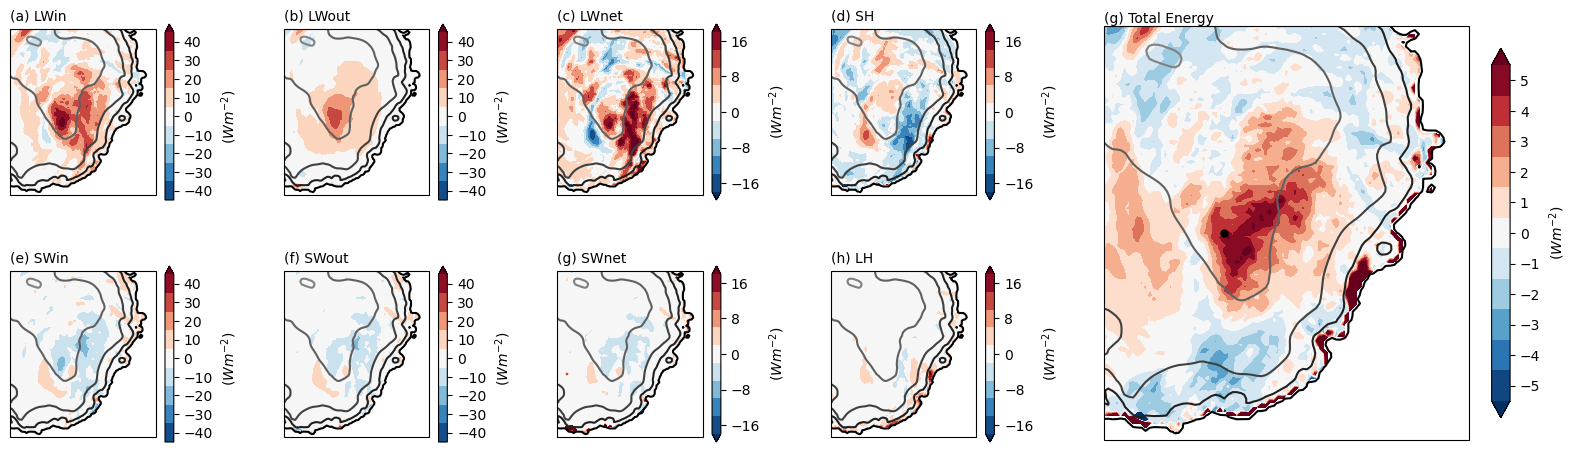

In [36]:
#############################################
# Plot terrein map
#############################################

min_height = 10

time_ix_ini = np.where(times == np.datetime64('2022-03-17T00'))[0][0]
time_ix_end = np.where(times == np.datetime64('2022-03-20T00'))[0][0]
  
#################
### Plot Norm ###
#Figure and axis
fig = plt.figure(figsize=[20,6])
spec = gridspec.GridSpec(ncols=6, nrows=2, figure=fig, hspace= 0.1, wspace=0.5)

### Background
ax1 = fig.add_subplot(spec[0, 0], projection=ccrs.SouthPolarStereo())
ax2 = fig.add_subplot(spec[0, 1], projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(spec[0, 2], projection=ccrs.SouthPolarStereo())
ax4 = fig.add_subplot(spec[0, 3], projection=ccrs.SouthPolarStereo())
ax5 = fig.add_subplot(spec[1, 0], projection=ccrs.SouthPolarStereo())
ax6 = fig.add_subplot(spec[1, 1], projection=ccrs.SouthPolarStereo())
ax7 = fig.add_subplot(spec[1, 2], projection=ccrs.SouthPolarStereo())
ax8 = fig.add_subplot(spec[1, 3], projection=ccrs.SouthPolarStereo())
ax9 = fig.add_subplot(spec[:, 4:], projection=ccrs.SouthPolarStereo())

CS1 = ax1.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS2 = ax2.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS3 = ax3.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS4 = ax4.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS5 = ax5.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS6 = ax6.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS7 = ax7.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS8 = ax8.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")
CS9 = ax9.contour(wrf.to_np(height), np.arange(10,9000,1000), cmap="gray", extend="both")

ax9.plot(wrf.to_np(CON_xy)[0], wrf.to_np(CON_xy)[1], 'ko', markersize=5, color='k')

#Calculate difference between the beginning and the end of the event
E_LWINC_hist_event_mean = wrf.to_np(E_LWINC_hist[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_LWOUT_hist_event_mean = wrf.to_np(-E_LWOUT_hist[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_SWINC_hist_event_mean = wrf.to_np(E_SWINC_hist[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_SWOUT_hist_event_mean = wrf.to_np(-E_SWOUT_hist[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_SENSH_hist_event_mean = wrf.to_np(E_SENSH_hist[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_LATEH_hist_event_mean = wrf.to_np(E_LATEH_hist[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_TOTAL_hist_event_mean = wrf.to_np(E_TOTAL_hist[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)

E_LWINC_past_event_mean = wrf.to_np(E_LWINC_past[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_LWOUT_past_event_mean = wrf.to_np(-E_LWOUT_past[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_SWINC_past_event_mean = wrf.to_np(E_SWINC_past[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_SWOUT_past_event_mean = wrf.to_np(-E_SWOUT_past[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_SENSH_past_event_mean = wrf.to_np(E_SENSH_past[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_LATEH_past_event_mean = wrf.to_np(E_LATEH_past[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)
E_TOTAL_past_event_mean = wrf.to_np(E_TOTAL_past[time_ix_ini:time_ix_end,:,:].where(height > min_height)).mean(axis=0)

fill1 = ax1.contourf(E_LWINC_hist_event_mean - E_LWINC_past_event_mean, np.arange(-45,45.1,10), cmap='RdBu_r', extend="max")
fill2 = ax2.contourf(E_LWOUT_hist_event_mean - E_LWOUT_past_event_mean, np.arange(-45,45.1,10), cmap='RdBu_r', extend="max")
fill3 = ax3.contourf(E_LWINC_hist_event_mean - E_LWOUT_hist_event_mean - (E_LWINC_past_event_mean - E_LWOUT_past_event_mean), np.arange(-18,18.1,4), cmap='RdBu_r', extend="both")

fill5 = ax5.contourf(E_SWINC_hist_event_mean - E_SWINC_past_event_mean, np.arange(-45,45.1,10), cmap='RdBu_r', extend="max")
fill6 = ax6.contourf(E_SWOUT_hist_event_mean - E_SWOUT_past_event_mean, np.arange(-45,45.1,10), cmap='RdBu_r', extend="max")
fill7 = ax7.contourf(E_SWINC_hist_event_mean - E_SWOUT_hist_event_mean - (E_SWINC_past_event_mean - E_SWOUT_past_event_mean), np.arange(-18,18.1,4), cmap='RdBu_r', extend="both")

fill4 = ax4.contourf(-E_SENSH_hist_event_mean - (-E_SENSH_past_event_mean), np.arange(-18,18.1,4), cmap='RdBu_r', extend="both")
fill8 = ax8.contourf(-E_LATEH_hist_event_mean - (-E_LATEH_past_event_mean), np.arange(-18,18.1,4), cmap='RdBu_r', extend="both")

ax1.set_title('(a) LWin', loc='left', fontsize=10)
ax2.set_title('(b) LWout', loc='left', fontsize=10)
ax3.set_title('(c) LWnet', loc='left', fontsize=10)

ax5.set_title('(e) SWin', loc='left', fontsize=10)
ax6.set_title('(f) SWout', loc='left', fontsize=10)
ax7.set_title('(g) SWnet', loc='left', fontsize=10)

ax4.set_title('(d) SH', loc='left', fontsize=10)
ax8.set_title('(h) LH', loc='left', fontsize=10)

cbar1 = plt.colorbar(fill1, shrink=0.8, ax=ax1); cbar1.set_label('($Wm^{-2}$)', labelpad=5)
cbar2 = plt.colorbar(fill2, shrink=0.8, ax=ax2); cbar2.set_label('($Wm^{-2}$)', labelpad=5)
cbar3 = plt.colorbar(fill3, shrink=0.8, ax=ax3); cbar3.set_label('($Wm^{-2}$)', labelpad=5)
cbar4 = plt.colorbar(fill4, shrink=0.8, ax=ax4); cbar4.set_label('($Wm^{-2}$)', labelpad=5)
cbar5 = plt.colorbar(fill5, shrink=0.8, ax=ax5); cbar5.set_label('($Wm^{-2}$)', labelpad=5)
cbar6 = plt.colorbar(fill6, shrink=0.8, ax=ax6); cbar6.set_label('($Wm^{-2}$)', labelpad=5)
cbar7 = plt.colorbar(fill7, shrink=0.8, ax=ax7); cbar7.set_label('($Wm^{-2}$)', labelpad=5)
cbar8 = plt.colorbar(fill8, shrink=0.8, ax=ax8); cbar8.set_label('($Wm^{-2}$)', labelpad=5)

fill9 = ax9.contourf(E_TOTAL_hist_event_mean - E_TOTAL_past_event_mean, np.arange(-5.5,5.6,1), cmap='RdBu_r', extend="both")
#fill9 = ax9.contourf(E_LWINC_hist_event_mean - E_LWOUT_hist_event_mean + E_SWINC_hist_event_mean-E_SWOUT_hist_event_mean - E_SENSH_hist_event_mean - E_LATEH_hist_event_mean, np.arange(-600,600.1,50), cmap='RdBu_r', extend="both")
cbar9 = plt.colorbar(fill9, shrink=0.8, ax=ax9)
cbar9.set_label('($Wm^{-2}$)', labelpad=5)
ax9.set_title('(g) Total Energy', pad=-2000, loc='left', fontsize=10)

cbar1.set_ticks(np.arange(-40,40.1,10))
cbar2.set_ticks(np.arange(-40,40.1,10))
cbar3.set_ticks(np.arange(-16,16.1,8))
cbar4.set_ticks(np.arange(-16,16.1,8))
cbar5.set_ticks(np.arange(-40,40.1,10))
cbar6.set_ticks(np.arange(-40,40.1,10))
cbar7.set_ticks(np.arange(-16,16.1,8))
cbar8.set_ticks(np.arange(-16,16.1,8))
cbar9.set_ticks(np.arange(-5,5.1,1))

for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]:
    ax.set_extent([132, 220, 30, 130], crs=ccrs.SouthPolarStereo())

In [29]:
# Mask arrays for statistics over Dome C region
mask = np.load("/users/gsergi/Jupyter_notebooks/PGW_ANT_20220315/mask_DomeC.npy")

E_LWINC_hist_event_msk = np.ma.array(E_LWINC_hist_event_mean, mask=mask).compressed()
E_LWOUT_hist_event_msk = np.ma.array(E_LWOUT_hist_event_mean, mask=mask).compressed()
E_SWINC_hist_event_msk = np.ma.array(E_SWINC_hist_event_mean, mask=mask).compressed()
E_SWOUT_hist_event_msk = np.ma.array(E_SWOUT_hist_event_mean, mask=mask).compressed()
E_SENSH_hist_event_msk = np.ma.array(E_SENSH_hist_event_mean, mask=mask).compressed()
E_LATEH_hist_event_msk = np.ma.array(E_LATEH_hist_event_mean, mask=mask).compressed()
E_TOTAL_hist_event_msk = np.ma.array(E_TOTAL_hist_event_mean, mask=mask).compressed()

E_LWINC_past_event_msk = np.ma.array(E_LWINC_past_event_mean, mask=mask).compressed()
E_LWOUT_past_event_msk = np.ma.array(E_LWOUT_past_event_mean, mask=mask).compressed()
E_SWINC_past_event_msk = np.ma.array(E_SWINC_past_event_mean, mask=mask).compressed()
E_SWOUT_past_event_msk = np.ma.array(E_SWOUT_past_event_mean, mask=mask).compressed()
E_SENSH_past_event_msk = np.ma.array(E_SENSH_past_event_mean, mask=mask).compressed()
E_LATEH_past_event_msk = np.ma.array(E_LATEH_past_event_mean, mask=mask).compressed()
E_TOTAL_past_event_msk = np.ma.array(E_TOTAL_past_event_mean, mask=mask).compressed()

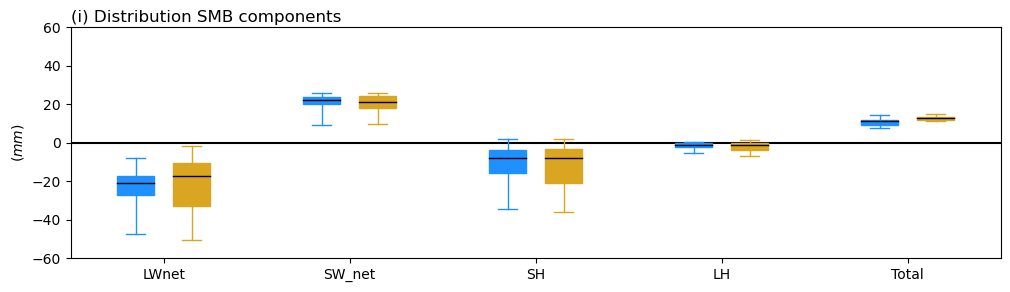

In [38]:
####################
## Plot the distribution of Energy components
####################
fig, (ax1)  = plt.subplots(1, 1, sharex=True, gridspec_kw={'hspace': 0.2}, figsize=(12,3), facecolor='white')
ax1.plot([0,10],[0,0], 'k-')

#Past Distributions
box1 = ax1.boxplot([(E_LWINC_past_event_msk-E_LWOUT_past_event_msk), (E_SWINC_past_event_msk - E_SWOUT_past_event_msk), E_SENSH_past_event_msk, E_LATEH_past_event_msk, E_TOTAL_past_event_msk], positions=[0.85, 1.85, 2.85, 3.85, 4.85], patch_artist=True, whis=[1,99], showfliers=False, widths = 0.2)
for item in ['boxes']:
        plt.setp(box1[item], color='DodgerBlue')
for item in ['whiskers', 'fliers', 'caps']:
        plt.setp(box1[item], color='DodgerBlue')
plt.setp(box1["fliers"], markeredgecolor='DodgerBlue')
plt.setp(box1["medians"], color='k')

#Present Distributions
box1 = ax1.boxplot([(E_LWINC_hist_event_msk-E_LWOUT_hist_event_msk), (E_SWINC_hist_event_msk - E_SWOUT_hist_event_msk), E_SENSH_hist_event_msk, E_LATEH_hist_event_msk, E_TOTAL_hist_event_msk], positions=[1.15, 2.15, 3.15, 4.15, 5.15], patch_artist=True, whis=[1,99], showfliers=False, widths = 0.2)
for item in ['boxes']:
        plt.setp(box1[item], color='GoldenRod')
for item in ['whiskers', 'fliers', 'caps']:
        plt.setp(box1[item], color='GoldenRod')
plt.setp(box1["fliers"], markeredgecolor='GoldenRod')
plt.setp(box1["medians"], color='k')

ax1.text(0, 1.01, '(i) Distribution SMB components', horizontalalignment='left', verticalalignment='bottom', transform=ax1.transAxes, fontsize=12)

#Settings
ax1.set_xlim(0.5,5.5)
ax1.set_ylim(-60,60)
ax1.set_xticks([1, 2, 3, 4, 5])
ax1.set_xticklabels(['LWnet', 'SW_net', 'SH', 'LH', 'Total'])
ax1.set_ylabel('($mm$)')

plt.savefig('Figure_Energy_DomeC_Boxplots.png', dpi=300, bbox_inches = 'tight')

In [42]:
from scipy import stats

#Function estimate mean difference with error bars
def mean_diff_with_error(x_hist, x_past, conf=0.95):
    x_hist = np.asarray(x_hist)
    x_past = np.asarray(x_past)

    mx, my = np.mean(x_hist), np.mean(x_past)
    vx, vy = np.var(x_hist, ddof=1), np.var(x_past, ddof=1)
    nx, ny = len(x_hist), len(x_past)

    # Mean difference
    diff = mx - my

    # Standard error (Welch)
    se = np.sqrt(vx/nx + vy/ny)

    # Welch–Satterthwaite degrees of freedom
    df = (vx/nx + vy/ny)**2 / ((vx/nx)**2/(nx-1) + (vy/ny)**2/(ny-1))

    # Critical t value
    tcrit = stats.t.ppf(1 - (1-conf)/2, df)

    # ± error
    err = tcrit * se

    return diff, err


print('Energy Component Differences (Past - Hist) at Dome C region')
print(stats.ttest_ind(E_LWINC_past_event_msk, E_LWINC_hist_event_msk, equal_var=False))
print(stats.ttest_ind(E_LWOUT_past_event_msk, E_LWOUT_hist_event_msk, equal_var=False))
print(stats.ttest_ind(E_LWINC_past_event_msk - E_LWOUT_past_event_msk, E_LWINC_hist_event_msk - E_LWOUT_hist_event_msk, equal_var=False))
print(stats.ttest_ind(E_SWINC_past_event_msk, E_SWINC_hist_event_msk, equal_var=False))
print(stats.ttest_ind(E_SWOUT_past_event_msk, E_SWOUT_hist_event_msk, equal_var=False))
print(stats.ttest_ind(E_SWINC_past_event_msk - E_SWOUT_past_event_msk, E_SWINC_hist_event_msk - E_SWOUT_hist_event_msk, equal_var=False))
print(stats.ttest_ind(E_SENSH_past_event_msk, E_SENSH_hist_event_msk, equal_var=False))
print(stats.ttest_ind(E_LATEH_past_event_msk, E_LATEH_hist_event_msk, equal_var=False))
print(stats.ttest_ind(E_TOTAL_past_event_msk, E_TOTAL_hist_event_msk, equal_var=False))

print("LWinc:",  mean_diff_with_error(E_LWINC_hist_event_msk, E_LWINC_past_event_msk))
print("LWout:",  mean_diff_with_error(E_LWOUT_hist_event_msk, E_LWOUT_past_event_msk))
print("LWnet:",  mean_diff_with_error(E_LWINC_hist_event_msk - E_LWOUT_hist_event_msk, E_LWINC_past_event_msk - E_LWOUT_past_event_msk))
print("SWin:", mean_diff_with_error(E_SWINC_hist_event_msk, E_SWINC_past_event_msk))
print("SWout:", mean_diff_with_error(E_SWOUT_hist_event_msk, E_SWOUT_past_event_msk))
print("SWnet:", mean_diff_with_error(E_SWINC_hist_event_msk - E_SWOUT_hist_event_msk, E_SWINC_past_event_msk - E_SWOUT_past_event_msk))
print("Rnet:", mean_diff_with_error(E_LWINC_hist_event_msk - E_LWOUT_hist_event_msk + E_SWINC_hist_event_msk - E_SWOUT_hist_event_msk, E_LWINC_past_event_msk - E_LWOUT_past_event_msk + E_SWINC_past_event_msk - E_SWOUT_past_event_msk))
print("SH:", mean_diff_with_error(-E_SENSH_hist_event_msk, -E_SENSH_past_event_msk))
print("LH:", mean_diff_with_error(-E_LATEH_hist_event_msk, -E_LATEH_past_event_msk))
print("Total:", mean_diff_with_error(E_TOTAL_hist_event_msk, E_TOTAL_past_event_msk))

Energy Component Differences (Past - Hist) at Dome C region
Ttest_indResult(statistic=-16.21176338822962, pvalue=7.033839776687917e-52)
Ttest_indResult(statistic=-41.02412218066985, pvalue=1.0947534431635541e-212)
Ttest_indResult(statistic=-1.4438550340287155, pvalue=0.1490915666389772)
Ttest_indResult(statistic=4.23268759578875, pvalue=2.507788529606839e-05)
Ttest_indResult(statistic=3.6244869709746927, pvalue=0.00030296051114505154)
Ttest_indResult(statistic=4.732656637408177, pvalue=2.493186721057127e-06)
Ttest_indResult(statistic=2.3950160786376244, pvalue=0.0167778107768844)
Ttest_indResult(statistic=4.959475097719499, pvalue=8.235741151676885e-07)
Ttest_indResult(statistic=-24.43895085203862, pvalue=1.269412723734699e-100)
LWinc: (15.957581, 1.9319077956761934)
LWout: (14.949463, 0.7151329677401164)
LWnet: (1.0081196, 1.3701249177123647)
SWin: (-2.9183044, 1.3528675804193468)
SWout: (-2.0327606, 1.100455614604251)
SWnet: (-0.8855438, 0.36712442393930494)
Rnet: (0.12257373, 1.2850